**Online Perakende Verisiyle Müşteri Davranışı Analizi ve Segmentasyonu**

**Veri Seti: Online Retail** — UCI Machine Learning Repository

**Modelleme Yaklaşımı**: RFM Analizi + K-Means Kümeleme

**Araştırma Soruları**

Bu projede aşağıdaki araştırma soruları yanıtlanacaktır:

1.Hangi ülkeler toplam gelire en fazla katkı sağlamaktadır?

2.Satış gelirleri aylara göre nasıl değişmektedir?

3.En çok gelir getiren ve en çok satılan ürünler hangileridir?

4.Müşteriler satın alma davranışlarına göre anlamlı segmentlere ayrılabilir mi?

İlk üç soru keşifsel veri analizi ile, dördüncü soru ise RFM + K-Means kümeleme modeliyle yanıtlanacaktır.

In [3]:
# Temel veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns

# Modelleme kütüphaneleri
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Dosya işlemleri
from pathlib import Path
import urllib.request
import zipfile

# Uyarıları azaltmak için
import warnings
warnings.filterwarnings("ignore")

# Grafik görünüm ayarları
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [4]:
# Veriyi okuma
df_raw = pd.read_excel("Online Retail.xlsx")

print("Veri başarıyla yüklendi.")
print(f"Satır sayısı: {df_raw.shape[0]:,}")
print(f"Sütun sayısı: {df_raw.shape[1]:,}")

df_raw.head()

Veri başarıyla yüklendi.
Satır sayısı: 541,909
Sütun sayısı: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


**İlk Veri İncelemesi**

Bu bölümde verinin boyutu, kolon isimleri, veri tipleri ve temel istatistikleri incelenir. Bu adım, temizlik stratejisini belirlemek için önemlidir.

In [5]:
# Veri setinin ilk 5 satırı
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [6]:
# Veri setinin son 5 satırı
df_raw.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,"12,680.00",France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,"12,680.00",France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,"12,680.00",France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,"12,680.00",France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,"12,680.00",France


In [7]:
# Satır ve sütun sayısı
df_raw.shape

(541909, 8)

In [8]:
# Kolon isimleri ve veri tipleri
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
# Sayısal değişkenlerin temel istatistikleri
df_raw.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,"541,909.00",541909,"541,909.00","406,829.00"
mean,9.55,2011-07-04 13:34:57.156386048,4.61,"15,287.69"
min,"-80,995.00",2010-12-01 08:26:00,"-11,062.06","12,346.00"
25%,1.00,2011-03-28 11:34:00,1.25,"13,953.00"
50%,3.00,2011-07-19 17:17:00,2.08,"15,152.00"
75%,10.00,2011-10-19 11:27:00,4.13,"16,791.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,218.08,NaN,96.76,"1,713.60"


In [10]:
# Kategorik değişkenlerin temel istatistikleri
df_raw.describe(include="object")

,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


**Veri Temizleme**

Bu veri setinde dikkat edilmesi gereken bazı noktalar vardır:

*CustomerID* alanında eksik değerler olabilir.

*Description* alanında eksik ya da boş kayıtlar olabilir.

*InvoiceNo* değeri C ile başlayan işlemler iptal / iade işlemleri olabilir.

*Quantity* negatifse bu genellikle iade veya iptal anlamına gelir.

*UnitPrice* sıfır veya negatifse geçerli satış analizi için uygun değildir.

*InvoiceDate* mutlaka tarih formatına çevrilmelidir.

*TotalPrice* = *Quantity* * *UnitPrice* değişkeni oluşturulmalıdır.

Bu projede ana analiz için yalnızca geçerli satış işlemleri kullanılacaktır. İptal/iade kayıtları ayrı olarak incelenecek, fakat gelir ve müşteri segmentasyonu analizinden çıkarılacaktır.

In [11]:
# Ham veriyi koruyup temizleme işlemleri için kopya alıyoruz
df = df_raw.copy()

# Kolon adlarında yanlışlıkla boşluk varsa temizleyelim
df.columns = df.columns.str.strip()

# Beklenen kolonları kontrol edelim
expected_columns = [
    "InvoiceNo", "StockCode", "Description", "Quantity",
    "InvoiceDate", "UnitPrice", "CustomerID", "Country"
]

missing_columns = [col for col in expected_columns if col not in df.columns]

if missing_columns:
    print("Eksik kolonlar:", missing_columns)
else:
    print("Tüm beklenen kolonlar veri setinde mevcut.")

Tüm beklenen kolonlar veri setinde mevcut.


In [12]:
# Veri tiplerini düzenleme

# Fatura ve ürün kodları sayısal işlem yapılmayacağı için string olarak tutulur
df["InvoiceNo"] = df["InvoiceNo"].astype("string")
df["StockCode"] = df["StockCode"].astype("string")

# Ürün açıklamasındaki baştaki/sondaki boşlukları temizleme
df["Description"] = df["Description"].astype("string").str.strip()

# Tarih alanını datetime tipine dönüştürme
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# CustomerID sayısal gibi görünse de kimlik alanıdır.
# Önce numeric'e çeviriyoruz, eksikleri koruyoruz.
df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce")

# Ülke bilgisindeki boşlukları temizleme
df["Country"] = df["Country"].astype("string").str.strip()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  string        
 1   StockCode    541909 non-null  string        
 2   Description  540455 non-null  string        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  string        
dtypes: datetime64[ns](1), float64(2), int64(1), string(4)
memory usage: 33.1 MB


**Eksik Veri Analizi**

Eksik veri, veri kalitesini doğrudan etkiler. Özellikle *CustomerID* eksikse müşteri bazlı segmentasyon yapılamaz. Bu nedenle müşteri segmentasyonu için *CustomerID* eksik olan kayıtlar çıkarılacaktır.

In [13]:
# Eksik değer sayıları ve yüzdeleri
missing_summary = pd.DataFrame({
    "MissingCount": df.isna().sum(),
    "MissingRatio_%": (df.isna().mean() * 100).round(2)
}).sort_values("MissingCount", ascending=False)

missing_summary

,MissingCount,MissingRatio_%
CustomerID,135080,24.93
Description,1454,0.27
StockCode,0,0.00
InvoiceNo,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


In [14]:
# Tekrarlayan kayıt sayısı
duplicate_count = df.duplicated().sum()
print(f"Tekrarlayan kayıt sayısı: {duplicate_count:,}")

Tekrarlayan kayıt sayısı: 5,268


**İptal / İade İşlemlerinin Belirlenmesi**

Bu veri setinde InvoiceNo değeri C ile başlıyorsa işlem genellikle iptal/iade işlemidir. Ayrıca Quantity negatif olan kayıtlar da geçerli satış olarak değerlendirilmez.

Bu kayıtları tamamen yok saymak yerine önce işaretliyoruz. Böylece istersek iptal/iade davranışını ayrıca inceleyebiliriz.

In [15]:
# İptal/iade işlemlerini işaretleme
df["IsCancelled"] = df["InvoiceNo"].str.startswith("C", na=False) | (df["Quantity"] < 0)

cancel_summary = df["IsCancelled"].value_counts().rename(index={False: "Normal işlem", True: "İptal/iade"})
cancel_summary

,count
IsCancelled,
Normal işlem,531285
İptal/iade,10624


In [16]:
# İptal/iade oranı
cancel_ratio = df["IsCancelled"].mean() * 100
print(f"İptal/iade olarak işaretlenen kayıt oranı: %{cancel_ratio:.2f}")

İptal/iade olarak işaretlenen kayıt oranı: %1.96


**Geçerli Satış Verisinin Oluşturulması**

Ana analizlerde aşağıdaki filtreler uygulanacaktır:

*İptal/iade* olmayan işlemler

*CustomerID* değeri bulunan işlemler

*Description* değeri bulunan işlemler

*Quantity* > 0

*UnitPrice* > 0

*Tekrarlayan kayıtların* kaldırılması

In [17]:
# Geçerli satış işlemlerini filtreleme
df_clean = df[
    (~df["IsCancelled"]) &
    (df["CustomerID"].notna()) &
    (df["Description"].notna()) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0) &
    (df["InvoiceDate"].notna())
].copy()

# Tekrarlayan kayıtları kaldırma
before_drop = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after_drop = df_clean.shape[0]

# CustomerID artık eksik olmadığı için string ID formatına çevrilebilir
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int).astype(str)

# Toplam satış tutarı
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Zaman bazlı analizler için ek değişkenler
df_clean["InvoiceYear"] = df_clean["InvoiceDate"].dt.year
df_clean["InvoiceMonth"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)
df_clean["InvoiceDay"] = df_clean["InvoiceDate"].dt.date
df_clean["DayOfWeek"] = df_clean["InvoiceDate"].dt.day_name()
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour

print(f"Temizleme öncesi geçerli satış satırı: {before_drop:,}")
print(f"Tekrarlayan kayıtlar kaldırıldıktan sonra: {after_drop:,}")
print(f"Kaldırılan tekrar sayısı: {before_drop - after_drop:,}")

df_clean.head()

Temizleme öncesi geçerli satış satırı: 397,884
Tekrarlayan kayıtlar kaldırıldıktan sonra: 392,692
Kaldırılan tekrar sayısı: 5,192


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,TotalPrice,InvoiceYear,InvoiceMonth,InvoiceDay,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30,2010,2010-12,2010-12-01,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010,2010-12,2010-12-01,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00,2010,2010-12,2010-12-01,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010,2010-12,2010-12-01,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010,2010-12,2010-12-01,Wednesday,8


In [18]:
# Temiz veri setinin genel özeti
print(f"Temiz veri satır sayısı: {df_clean.shape[0]:,}")
print(f"Temiz veri sütun sayısı: {df_clean.shape[1]:,}")
print(f"Benzersiz müşteri sayısı: {df_clean['CustomerID'].nunique():,}")
print(f"Benzersiz fatura sayısı: {df_clean['InvoiceNo'].nunique():,}")
print(f"Benzersiz ürün sayısı: {df_clean['StockCode'].nunique():,}")
print(f"Ülke sayısı: {df_clean['Country'].nunique():,}")
print(f"Toplam gelir: {df_clean['TotalPrice'].sum():,.2f}")
print(f"Tarih aralığı: {df_clean['InvoiceDate'].min()} - {df_clean['InvoiceDate'].max()}")

Temiz veri satır sayısı: 392,692
Temiz veri sütun sayısı: 15
Benzersiz müşteri sayısı: 4,338
Benzersiz fatura sayısı: 18,532
Benzersiz ürün sayısı: 3,665
Ülke sayısı: 37
Toplam gelir: 8,887,208.89
Tarih aralığı: 2010-12-01 08:26:00 - 2011-12-09 12:50:00


**Aykırı Değer Analizi**

E-ticaret verilerinde bazı müşteriler veya siparişler çok yüksek adetlerde ürün alabilir. Bu her zaman hata anlamına gelmez; örneğin toptancı müşteriler yüksek miktarlı alışveriş yapabilir.

Bu nedenle aykırı değerleri doğrudan silmek yerine:

1.Önce IQR yöntemiyle aykırı değerleri tespit ediyoruz.

2.Ana EDA'da gerçek değerleri koruyoruz.

3.Modelleme aşamasında RFM değerlerini log1p ile dönüştürerek aşırı büyük değerlerin etkisini azaltıyoruz.

In [19]:
def iqr_bounds(series):
    """IQR yöntemine göre alt ve üst sınır hesaplar."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

outlier_rows = []

for col in ["Quantity", "UnitPrice", "TotalPrice"]:
    lower, upper = iqr_bounds(df_clean[col])
    outlier_count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_ratio = outlier_count / len(df_clean) * 100

    outlier_rows.append({
        "Column": col,
        "LowerBound": lower,
        "UpperBound": upper,
        "OutlierCount": outlier_count,
        "OutlierRatio_%": outlier_ratio
    })

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary

,Column,LowerBound,UpperBound,OutlierCount,OutlierRatio_%
0,Quantity,-13.00,27.00,25616,6.52
1,UnitPrice,-2.50,7.50,34112,8.69
2,TotalPrice,-17.32,42.07,31231,7.95


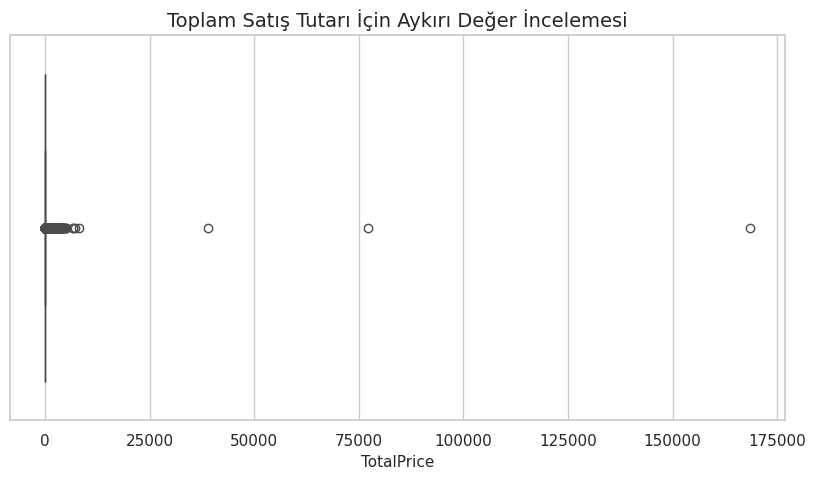

In [20]:
# Aykırı değerleri görsel olarak inceleme: boxplot

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean["TotalPrice"])
plt.title("Toplam Satış Tutarı İçin Aykırı Değer İncelemesi")
plt.xlabel("TotalPrice")
plt.show()

**Keşifsel Veri Analizi — EDA**

# Bu bölümde veri setinin genel davranışı incelenir.

Kullanılacak görselleştirme türleri:

Bar chart

Line chart

Histogram

Boxplot

Scatter plot

Heatmap


**Genel Sayısal İstatistikler**

In [21]:
# Temiz veri üzerinden temel istatistikler
df_clean[["Quantity", "UnitPrice", "TotalPrice"]].describe()

,Quantity,UnitPrice,TotalPrice
count,"392,692.00","392,692.00","392,692.00"
mean,13.12,3.13,22.63
std,180.49,22.24,311.10
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,6.00,1.95,12.45
75%,12.00,3.75,19.80
max,"80,995.00","8,142.75","168,469.60"


In [22]:
# Sipariş bazlı özet tablo
invoice_summary = df_clean.groupby("InvoiceNo").agg(
    InvoiceDate=("InvoiceDate", "min"),
    CustomerID=("CustomerID", "first"),
    Country=("Country", "first"),
    ItemCount=("StockCode", "count"),
    TotalQuantity=("Quantity", "sum"),
    OrderValue=("TotalPrice", "sum")
).reset_index()

invoice_summary.head()

,InvoiceNo,InvoiceDate,CustomerID,Country,ItemCount,TotalQuantity,OrderValue
0,536365,2010-12-01 08:26:00,17850,United Kingdom,7,40,139.12
1,536366,2010-12-01 08:28:00,17850,United Kingdom,2,12,22.20
2,536367,2010-12-01 08:34:00,13047,United Kingdom,12,83,278.73
3,536368,2010-12-01 08:34:00,13047,United Kingdom,4,15,70.05
4,536369,2010-12-01 08:35:00,13047,United Kingdom,1,3,17.85


In [23]:
invoice_summary[["ItemCount", "TotalQuantity", "OrderValue"]].describe()

,ItemCount,TotalQuantity,OrderValue
count,"18,532.00","18,532.00","18,532.00"
mean,21.19,278.01,479.56
std,24.35,972.39,"1,678.08"
min,1.00,1.00,0.38
25%,6.00,74.00,157.34
50%,15.00,154.00,302.57
75%,27.00,290.00,469.57
max,542.00,"80,995.00","168,469.60"


**Görselleştirme 1 — Ülkelere Göre Gelir Dağılımı**

Bu grafik, hangi ülkelerin toplam gelire daha fazla katkı sağladığını gösterir.

In [24]:
country_revenue = df_clean.groupby("Country").agg(
    Revenue=("TotalPrice", "sum"),
    OrderCount=("InvoiceNo", "nunique"),
    CustomerCount=("CustomerID", "nunique")
).sort_values("Revenue", ascending=False)

country_revenue["RevenueShare_%"] = country_revenue["Revenue"] / country_revenue["Revenue"].sum() * 100

country_revenue.head(10)

,Revenue,OrderCount,CustomerCount,RevenueShare_%
Country,,,,
United Kingdom,"7,285,024.64",16646,3920,81.97
Netherlands,"285,446.34",94,9,3.21
EIRE,"265,262.46",260,3,2.98
Germany,"228,678.40",457,94,2.57
France,"208,934.31",389,87,2.35
Australia,"138,453.81",57,9,1.56
Spain,"61,558.56",90,30,0.69
Switzerland,"56,443.95",51,21,0.64
Belgium,"41,196.34",98,25,0.46


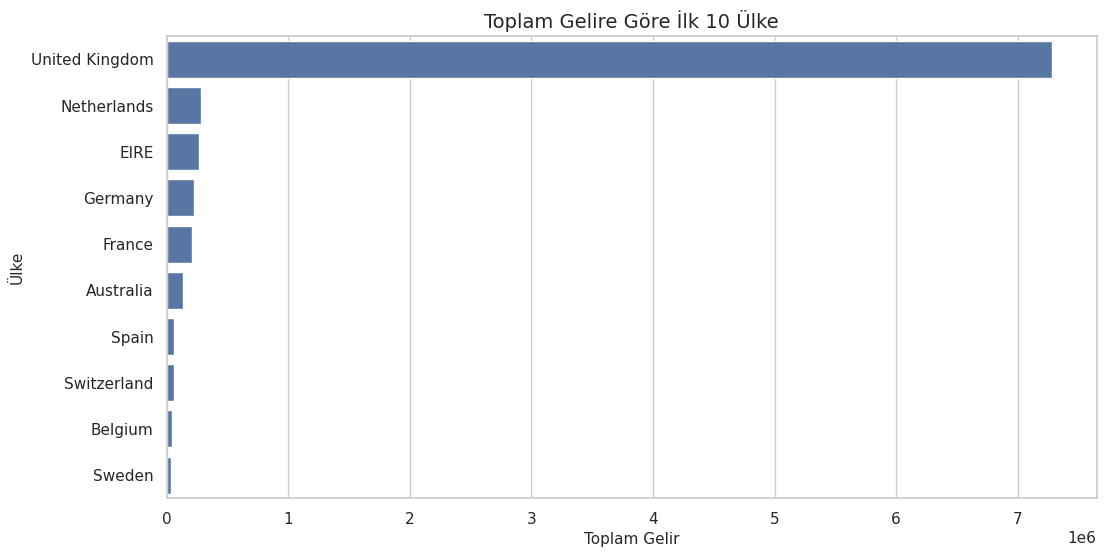

In [25]:
top_countries = country_revenue.head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x="Revenue", y="Country")
plt.title("Toplam Gelire Göre İlk 10 Ülke")
plt.xlabel("Toplam Gelir")
plt.ylabel("Ülke")
plt.show()

**Görselleştirme 2 — Aylık Satış Geliri Trendi**

Bu grafik, satış gelirlerinin zaman içinde nasıl değiştiğini gösterir.

In [26]:
monthly_revenue = df_clean.groupby("InvoiceMonth").agg(
    Revenue=("TotalPrice", "sum"),
    OrderCount=("InvoiceNo", "nunique"),
    CustomerCount=("CustomerID", "nunique")
).reset_index()

monthly_revenue

,InvoiceMonth,Revenue,OrderCount,CustomerCount
0,2010-12,"570,422.73",1400,885
1,2011-01,"568,101.31",987,741
2,2011-02,"446,084.92",997,758
3,2011-03,"594,081.76",1321,974
4,2011-04,"468,374.33",1149,856
5,2011-05,"677,355.15",1555,1056
6,2011-06,"660,046.05",1393,991
7,2011-07,"598,962.90",1331,949
8,2011-08,"644,051.04",1280,935
9,2011-09,"950,690.20",1755,1266


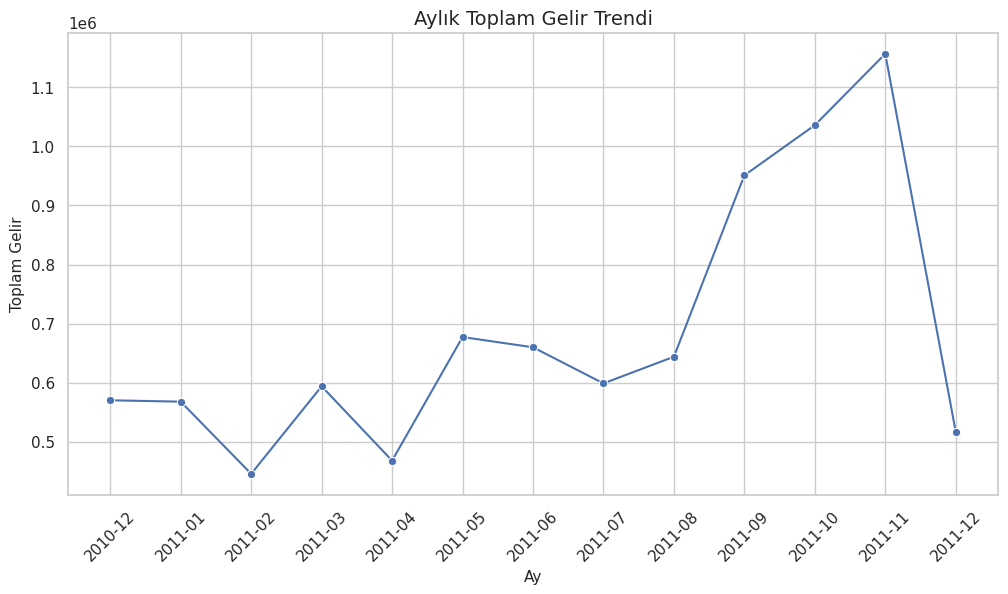

In [27]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_revenue, x="InvoiceMonth", y="Revenue", marker="o")
plt.title("Aylık Toplam Gelir Trendi")
plt.xlabel("Ay")
plt.ylabel("Toplam Gelir")
plt.xticks(rotation=45)
plt.show()

**Görselleştirme 3 — Sipariş Tutarı Dağılımı**

Histogram, sipariş tutarlarının nasıl dağıldığını gösterir. E-ticaret verilerinde genellikle çok sayıda düşük tutarlı, az sayıda yüksek tutarlı sipariş bulunur.

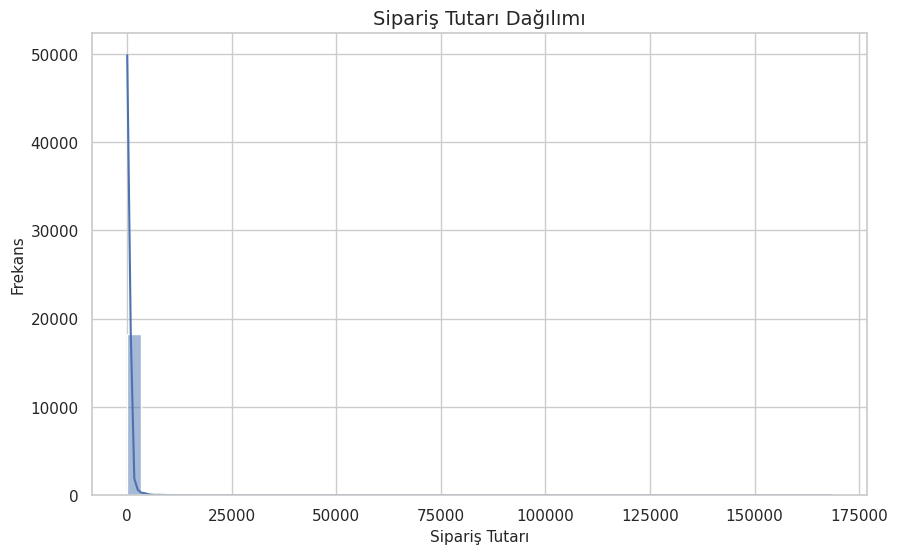

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(invoice_summary["OrderValue"], bins=50, kde=True)
plt.title("Sipariş Tutarı Dağılımı")
plt.xlabel("Sipariş Tutarı")
plt.ylabel("Frekans")
plt.show()

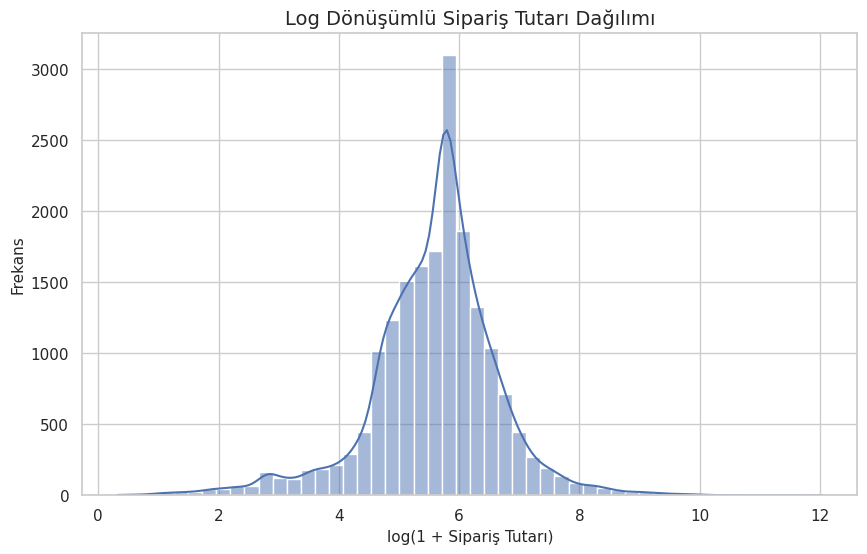

In [29]:
# Aşırı büyük siparişler dağılımı sıkıştırabileceği için log dönüşümlü histogram
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(invoice_summary["OrderValue"]), bins=50, kde=True)
plt.title("Log Dönüşümlü Sipariş Tutarı Dağılımı")
plt.xlabel("log(1 + Sipariş Tutarı)")
plt.ylabel("Frekans")
plt.show()

**Görselleştirme 4 — Ülkelere Göre Sipariş Tutarı Boxplot**

Boxplot, ülkeler bazında sipariş tutarlarının dağılımını ve aykırı değerleri karşılaştırmak için kullanılır.

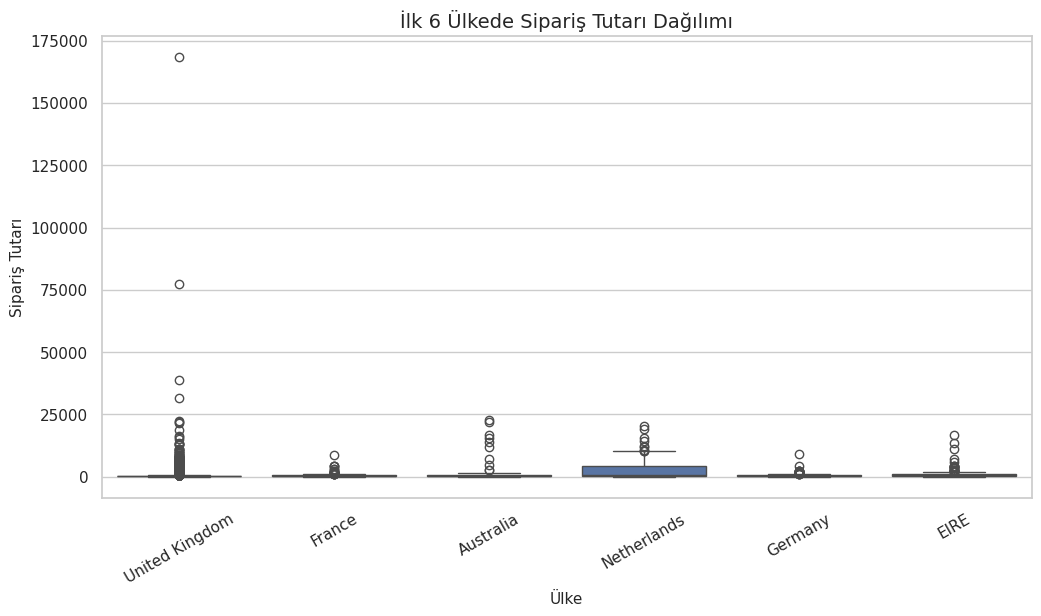

In [30]:
# En çok gelir getiren ilk 6 ülke için boxplot çizelim
top_6_countries = country_revenue.head(6).index

invoice_top_countries = invoice_summary[invoice_summary["Country"].isin(top_6_countries)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=invoice_top_countries, x="Country", y="OrderValue")
plt.title("İlk 6 Ülkede Sipariş Tutarı Dağılımı")
plt.xlabel("Ülke")
plt.ylabel("Sipariş Tutarı")
plt.xticks(rotation=30)
plt.show()

**Görselleştirme 5 — En Çok Gelir Getiren Ürünler**

Ürün açıklamaları üzerinden en çok gelir getiren ürünler incelenir.

In [31]:
product_revenue = df_clean.groupby("Description").agg(
    Revenue=("TotalPrice", "sum"),
    QuantitySold=("Quantity", "sum"),
    OrderCount=("InvoiceNo", "nunique")
).sort_values("Revenue", ascending=False)

product_revenue.head(15)

,Revenue,QuantitySold,OrderCount
Description,,,
"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1
REGENCY CAKESTAND 3 TIER,"142,264.75",12374,1703
WHITE HANGING HEART T-LIGHT HOLDER,"100,392.10",36706,1971
JUMBO BAG RED RETROSPOT,"85,040.54",46078,1600
MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73",77916,195
POSTAGE,"77,803.96",3120,1099
PARTY BUNTING,"68,785.23",15279,1379
ASSORTED COLOUR BIRD ORNAMENT,"56,413.03",35263,1375
Manual,"53,419.93",6933,253


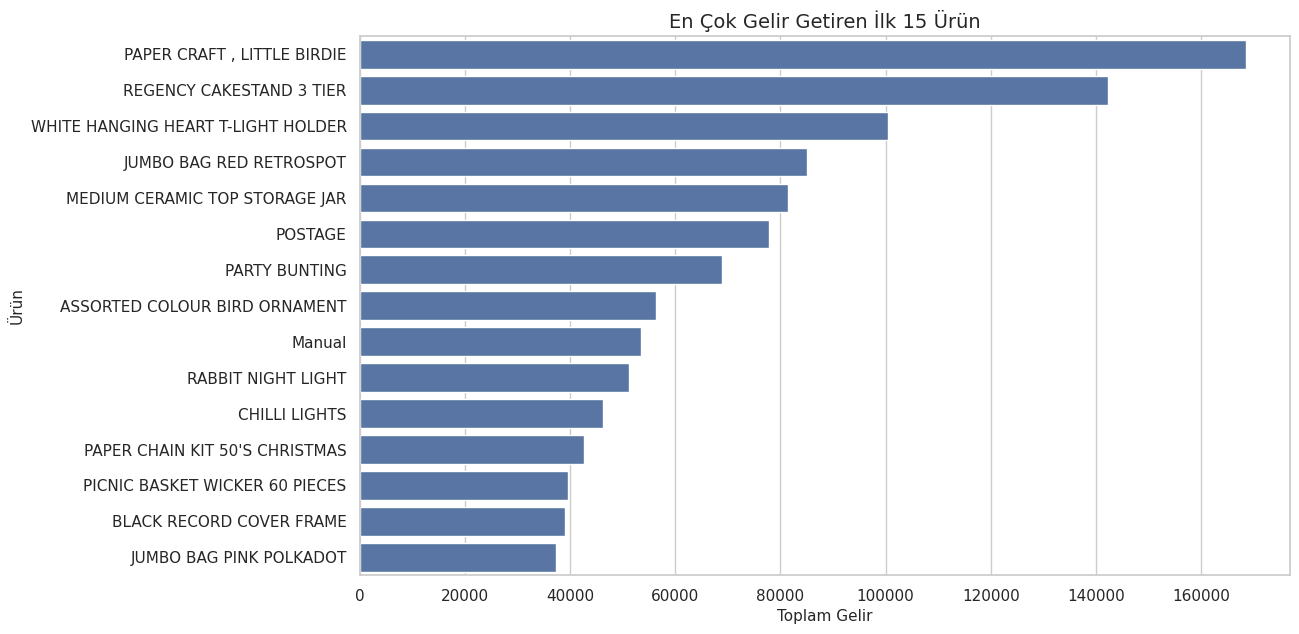

In [32]:
top_products = product_revenue.head(15).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(data=top_products, x="Revenue", y="Description")
plt.title("En Çok Gelir Getiren İlk 15 Ürün")
plt.xlabel("Toplam Gelir")
plt.ylabel("Ürün")
plt.show()

**Görselleştirme 6 — Sayısal Değişkenler Arası Korelasyon**

Korelasyon ısı haritası, sayısal değişkenler arasındaki ilişkileri gösterir.

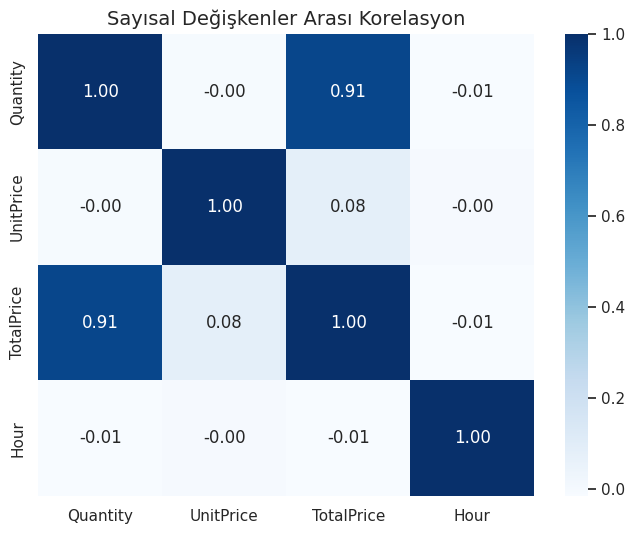

In [33]:
numeric_cols = ["Quantity", "UnitPrice", "TotalPrice", "Hour"]
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Sayısal Değişkenler Arası Korelasyon")
plt.show()

H**angi ülkeler toplam gelire en fazla katkı sağlamaktadır?**

In [34]:
top_country = country_revenue.iloc[0]

print("En çok gelir getiren ülke:")
print(f"Ülke: {country_revenue.index[0]}")
print(f"Gelir: {top_country['Revenue']:,.2f}")
print(f"Toplam gelir içindeki payı: %{top_country['RevenueShare_%']:.2f}")

country_revenue.head(10)

En çok gelir getiren ülke:
Ülke: United Kingdom
Gelir: 7,285,024.64
Toplam gelir içindeki payı: %81.97


,Revenue,OrderCount,CustomerCount,RevenueShare_%
Country,,,,
United Kingdom,"7,285,024.64",16646,3920,81.97
Netherlands,"285,446.34",94,9,3.21
EIRE,"265,262.46",260,3,2.98
Germany,"228,678.40",457,94,2.57
France,"208,934.31",389,87,2.35
Australia,"138,453.81",57,9,1.56
Spain,"61,558.56",90,30,0.69
Switzerland,"56,443.95",51,21,0.64
Belgium,"41,196.34",98,25,0.46


**Satış gelirleri aylara göre nasıl değişmektedir?**

In [35]:
best_month = monthly_revenue.loc[monthly_revenue["Revenue"].idxmax()]
worst_month = monthly_revenue.loc[monthly_revenue["Revenue"].idxmin()]

print("En yüksek gelirli ay:")
print(f"Ay: {best_month['InvoiceMonth']}, Gelir: {best_month['Revenue']:,.2f}")

print("\nEn düşük gelirli ay:")
print(f"Ay: {worst_month['InvoiceMonth']}, Gelir: {worst_month['Revenue']:,.2f}")

monthly_revenue

En yüksek gelirli ay:
Ay: 2011-11, Gelir: 1,156,205.61

En düşük gelirli ay:
Ay: 2011-02, Gelir: 446,084.92


,InvoiceMonth,Revenue,OrderCount,CustomerCount
0,2010-12,"570,422.73",1400,885
1,2011-01,"568,101.31",987,741
2,2011-02,"446,084.92",997,758
3,2011-03,"594,081.76",1321,974
4,2011-04,"468,374.33",1149,856
5,2011-05,"677,355.15",1555,1056
6,2011-06,"660,046.05",1393,991
7,2011-07,"598,962.90",1331,949
8,2011-08,"644,051.04",1280,935
9,2011-09,"950,690.20",1755,1266


**En çok gelir getiren ve en çok satılan ürünler hangileridir?**

In [36]:
top_revenue_products = product_revenue.head(10)

top_quantity_products = df_clean.groupby("Description").agg(
    QuantitySold=("Quantity", "sum"),
    Revenue=("TotalPrice", "sum")
).sort_values("QuantitySold", ascending=False).head(10)

print("Gelire göre ilk 10 ürün:")
display(top_revenue_products)

print("\nSatış adedine göre ilk 10 ürün:")
display(top_quantity_products)

Gelire göre ilk 10 ürün:


,Revenue,QuantitySold,OrderCount
Description,,,
"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1
REGENCY CAKESTAND 3 TIER,"142,264.75",12374,1703
WHITE HANGING HEART T-LIGHT HOLDER,"100,392.10",36706,1971
JUMBO BAG RED RETROSPOT,"85,040.54",46078,1600
MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73",77916,195
POSTAGE,"77,803.96",3120,1099
PARTY BUNTING,"68,785.23",15279,1379
ASSORTED COLOUR BIRD ORNAMENT,"56,413.03",35263,1375
Manual,"53,419.93",6933,253



Satış adedine göre ilk 10 ürün:


,QuantitySold,Revenue
Description,,
"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60"
MEDIUM CERAMIC TOP STORAGE JAR,77916,"81,416.73"
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319,"13,558.41"
JUMBO BAG RED RETROSPOT,46078,"85,040.54"
WHITE HANGING HEART T-LIGHT HOLDER,36706,"100,392.10"
ASSORTED COLOUR BIRD ORNAMENT,35263,"56,413.03"
PACK OF 72 RETROSPOT CAKE CASES,33670,"16,381.88"
POPCORN HOLDER,30919,"23,417.51"
RABBIT NIGHT LIGHT,27153,"51,251.24"


**Müşteriler satın alma davranışlarına göre segmentlere ayrılabilir mi?**

Bu soruyu yanıtlamak için RFM analizi kullanılacaktır.

RFM bileşenleri:

*Recency*: Müşterinin son alışverişinden bu yana geçen gün sayısı

*Frequency*: Müşterinin toplam sipariş sayısı

*Monetary*: Müşterinin toplam harcama tutarı

Daha düşük Recency, daha güncel müşteri anlamına gelir.
Daha yüksek Frequency ve Monetary, daha değerli müşteri davranışı anlamına gelir.

In [37]:
# Referans tarih: veri setindeki son işlem tarihinden 1 gün sonrası
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    AvgOrderValue=("TotalPrice", "mean")
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgOrderValue
0,12346,326,1,"77,183.60",74215,"77,183.60"
1,12347,2,7,"4,310.00",2458,23.68
2,12348,75,4,"1,797.24",2341,57.98
3,12349,19,1,"1,757.55",631,24.08
4,12350,310,1,334.40,197,19.67


In [38]:
# RFM temel istatistikleri
rfm[["Recency", "Frequency", "Monetary", "TotalQuantity", "AvgOrderValue"]].describe()

,Recency,Frequency,Monetary,TotalQuantity,AvgOrderValue
count,"4,338.00","4,338.00","4,338.00","4,338.00","4,338.00"
mean,92.54,4.27,"2,048.69","1,187.64",68.38
std,100.01,7.70,"8,985.23","5,043.62","1,467.92"
min,1.00,1.00,3.75,1.00,2.14
25%,18.00,1.00,306.48,159.00,12.39
50%,51.00,2.00,668.57,378.00,17.76
75%,142.00,5.00,"1,660.60",989.75,24.88
max,374.00,209.00,"280,206.02","196,915.00","77,183.60"


**RFM Dağılımları**
# RFM değişkenleri genellikle sağa çarpık dağılıma sahiptir. Bu nedenle modelleme öncesinde log1p dönüşümü uygulanacaktır. log1p(x) = log(1 + x) olduğu için sıfır değerlerde hata oluşturmaz.

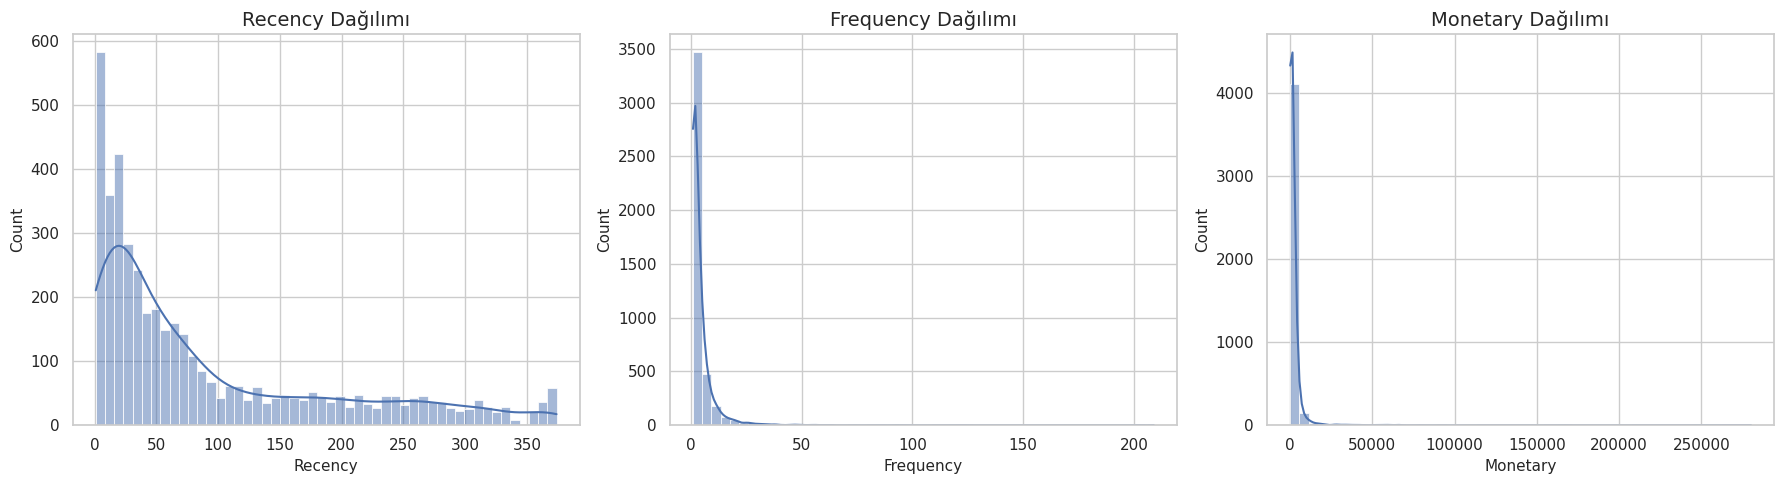

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Recency Dağılımı")

sns.histplot(rfm["Frequency"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Frequency Dağılımı")

sns.histplot(rfm["Monetary"], bins=50, kde=True, ax=axes[2])
axes[2].set_title("Monetary Dağılımı")

plt.tight_layout()
plt.show()

In [40]:
# Log dönüşümlü RFM değişkenleri
rfm_model = rfm[["Recency", "Frequency", "Monetary"]].copy()

rfm_log = np.log1p(rfm_model)

rfm_log.head()

,Recency,Frequency,Monetary
0,5.79,0.69,11.25
1,1.10,2.08,8.37
2,4.33,1.61,7.49
3,3.00,0.69,7.47
4,5.74,0.69,5.82


In [41]:
# Ölçekleme
# K-Means mesafe temelli bir algoritmadır.
# Bu yüzden değişkenlerin aynı ölçeğe getirilmesi gerekir.

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency_scaled", "Frequency_scaled", "Monetary_scaled"]
)

rfm_scaled_df.head()

,Recency_scaled,Frequency_scaled,Monetary_scaled
0,1.46,-0.96,3.71
1,-2.04,1.07,1.41
2,0.37,0.39,0.72
3,-0.62,-0.96,0.70
4,1.42,-0.96,-0.61


**Modelleme — K-Means ile Müşteri Segmentasyonu**

Bu projede temel modelleme yöntemi olarak K-Means kümeleme kullanılacaktır.

K-Means, benzer özelliklere sahip müşterileri aynı kümelere ayırır. Bu problemde modelin amacı müşterileri satın alma davranışlarına göre segmentlere bölmektir.


### Küme Sayısının Belirlenmesi
​
Küme sayısını belirlemek için iki ölçüm kullanılacaktır:
​
1. **Elbow Method:** Küme sayısı arttıkça hata azalır. Kırılma noktası uygun küme sayısı olabilir.
2. **Silhouette Score:** Kümelerin ne kadar ayrıştığını ölçer. Daha yüksek skor genellikle daha iyi ayrışma anlamına gelir.


In [42]:
inertias = []
silhouette_scores = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

model_selection = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "SilhouetteScore": silhouette_scores
})

model_selection

,k,Inertia,SilhouetteScore
0,2,"6,483.59",0.43
1,3,"4,869.49",0.34
2,4,"3,939.05",0.34
3,5,"3,296.71",0.32
4,6,"2,855.76",0.31
5,7,"2,548.82",0.31
6,8,"2,336.34",0.30


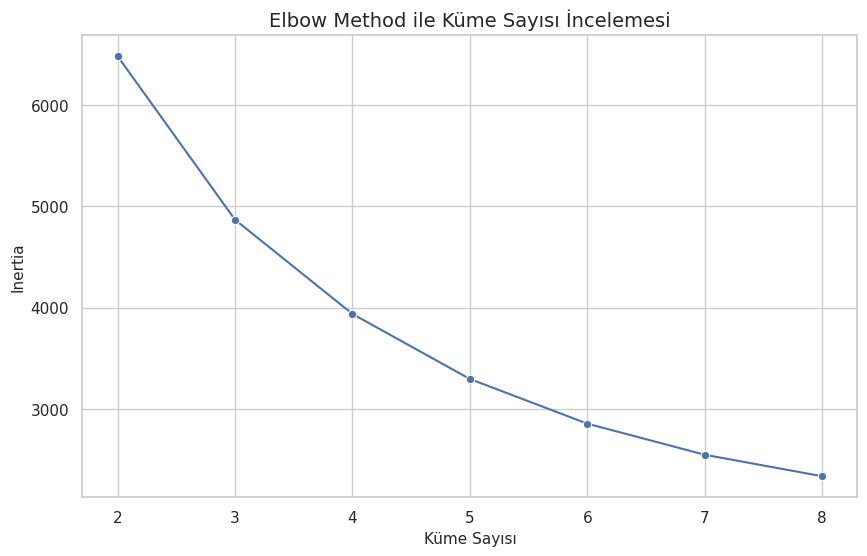

In [43]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=model_selection, x="k", y="Inertia", marker="o")
plt.title("Elbow Method ile Küme Sayısı İncelemesi")
plt.xlabel("Küme Sayısı")
plt.ylabel("Inertia")
plt.show()

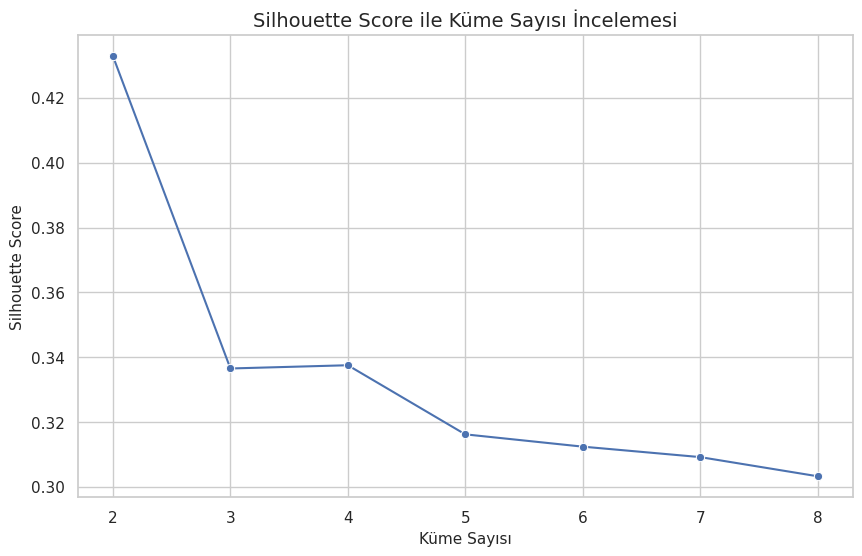

In [44]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=model_selection, x="k", y="SilhouetteScore", marker="o")
plt.title("Silhouette Score ile Küme Sayısı İncelemesi")
plt.xlabel("Küme Sayısı")
plt.ylabel("Silhouette Score")
plt.show()

### Final K-Means Modeli

Aşağıdaki hücrede en yüksek silhouette skorunu veren küme sayısı otomatik seçilir.
Dilersen raporda yorum yaparken 3 veya 4 gibi daha kolay açıklanabilir bir küme sayısını manuel olarak da seçebilirsin.

Bu notebook'ta varsayılan olarak otomatik seçim kullanılmaktadır.

In [45]:
# En iyi k değerini silhouette skoruna göre seçiyoruz
best_k = model_selection.loc[model_selection["SilhouetteScore"].idxmax(), "k"]

print(f"Seçilen küme sayısı: {best_k}")

final_kmeans = KMeans(n_clusters=int(best_k), random_state=42, n_init=10)
rfm["Cluster"] = final_kmeans.fit_predict(rfm_scaled)

final_silhouette = silhouette_score(rfm_scaled, rfm["Cluster"])

print(f"Final model silhouette skoru: {final_silhouette:.3f}")

rfm.head()

Seçilen küme sayısı: 2
Final model silhouette skoru: 0.433


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgOrderValue,Cluster
0,12346,326,1,"77,183.60",74215,"77,183.60",1
1,12347,2,7,"4,310.00",2458,23.68,1
2,12348,75,4,"1,797.24",2341,57.98,1
3,12349,19,1,"1,757.55",631,24.08,0
4,12350,310,1,334.40,197,19.67,0


###  Segment Profillerinin İncelenmesi

Bu bölümde her kümenin ortalama RFM değerleri incelenir.
Bu tablo, kümelerin iş açısından nasıl yorumlanacağını gösterir.

In [46]:
cluster_profile = rfm.groupby("Cluster").agg(
    CustomerCount=("CustomerID", "count"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean"),
    TotalRevenue=("Monetary", "sum")
).reset_index()

cluster_profile["CustomerShare_%"] = cluster_profile["CustomerCount"] / cluster_profile["CustomerCount"].sum() * 100
cluster_profile["RevenueShare_%"] = cluster_profile["TotalRevenue"] / cluster_profile["TotalRevenue"].sum() * 100

cluster_profile = cluster_profile.sort_values("AvgMonetary", ascending=False)

cluster_profile

,Cluster,CustomerCount,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue,CustomerShare_%,RevenueShare_%
1,1,1666,25.89,8.44,"4,539.60","7,562,979.20",38.40,85.10
0,0,2672,134.09,1.67,495.59,"1,324,229.69",61.60,14.90


**Segment İsimlendirme**

K-Means modelinin verdiği kümeler 0, 1, 2 gibi sayısal etiketlerden oluşur. Bu etiketler iş açısından anlamlı değildir.

Bu nedenle kümeler RFM profiline göre isimlendirilecektir.

In [47]:
# Segmentleri iş açısından anlamlı hale getirme
# Mantık:
# - Monetary ve Frequency yüksek, Recency düşük ise müşteri daha değerlidir.
# - Recency yüksek, Frequency/Monetary düşük ise müşteri daha riskli veya düşük değerlidir.

profile_for_names = cluster_profile.copy()

# Skor üretimi:
# AvgRecency için düşük değer daha iyi olduğu için ascending=False ile düşük değerler daha yüksek rank alır.
profile_for_names["RecencyScore"] = profile_for_names["AvgRecency"].rank(ascending=False)
profile_for_names["FrequencyScore"] = profile_for_names["AvgFrequency"].rank(ascending=True)
profile_for_names["MonetaryScore"] = profile_for_names["AvgMonetary"].rank(ascending=True)

profile_for_names["BusinessScore"] = (
    profile_for_names["RecencyScore"] +
    profile_for_names["FrequencyScore"] +
    profile_for_names["MonetaryScore"]
)

profile_for_names = profile_for_names.sort_values("BusinessScore", ascending=False).reset_index(drop=True)

segment_labels = [
    "En Değerli Müşteriler",
    "Sadık / Potansiyel Müşteriler",
    "Geliştirilebilir Müşteriler",
    "Riskteki veya Düşük Değerli Müşteriler",
    "Çok Düşük Aktivite",
    "Niş Segment",
    "Düşük Harcama Segmenti"
]

cluster_to_segment = {}

for i, row in profile_for_names.iterrows():
    cluster_to_segment[row["Cluster"]] = segment_labels[i] if i < len(segment_labels) else f"Segment {i+1}"

rfm["SegmentName"] = rfm["Cluster"].map(cluster_to_segment)

profile_with_names = rfm.groupby(["Cluster", "SegmentName"]).agg(
    CustomerCount=("CustomerID", "count"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean"),
    TotalRevenue=("Monetary", "sum")
).reset_index()

profile_with_names["CustomerShare_%"] = profile_with_names["CustomerCount"] / profile_with_names["CustomerCount"].sum() * 100
profile_with_names["RevenueShare_%"] = profile_with_names["TotalRevenue"] / profile_with_names["TotalRevenue"].sum() * 100

profile_with_names.sort_values("AvgMonetary", ascending=False)

,Cluster,SegmentName,CustomerCount,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue,CustomerShare_%,RevenueShare_%
1,1,En Değerli Müşteriler,1666,25.89,8.44,"4,539.60","7,562,979.20",38.40,85.10
0,0,Sadık / Potansiyel Müşteriler,2672,134.09,1.67,495.59,"1,324,229.69",61.60,14.90


**Görselleştirme — Segment Büyüklükleri**

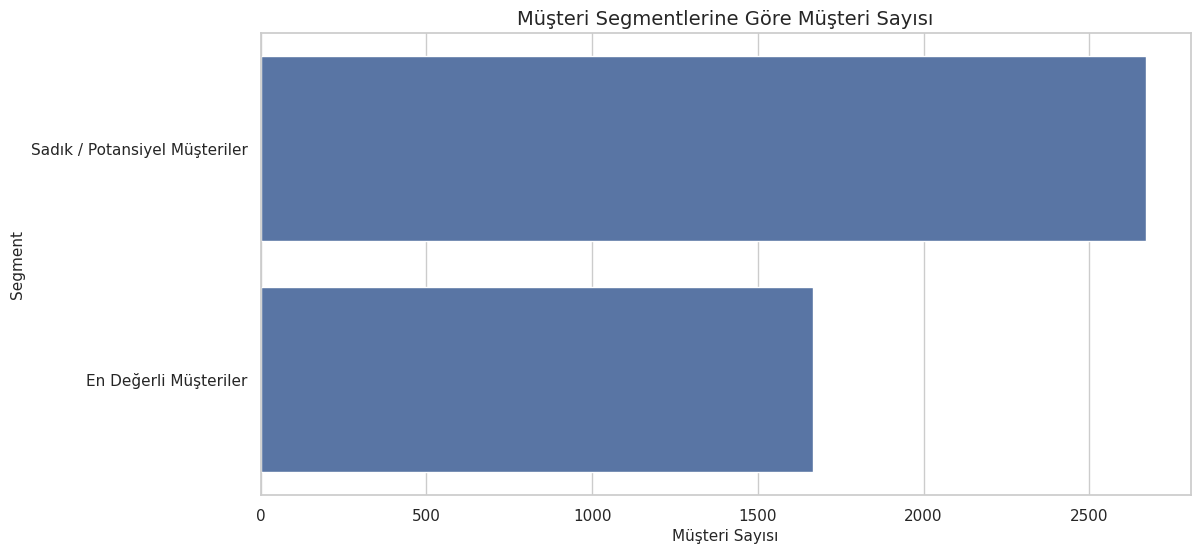

In [48]:
segment_counts = rfm["SegmentName"].value_counts().reset_index()
segment_counts.columns = ["SegmentName", "CustomerCount"]

plt.figure(figsize=(12, 6))
sns.barplot(data=segment_counts, x="CustomerCount", y="SegmentName")
plt.title("Müşteri Segmentlerine Göre Müşteri Sayısı")
plt.xlabel("Müşteri Sayısı")
plt.ylabel("Segment")
plt.show()

**Görselleştirme — Frequency ve Monetary İlişkisi**

Bu scatter plot, müşterilerin sipariş sıklığı ve toplam harcama düzeyine göre nasıl kümelendiğini gösterir.

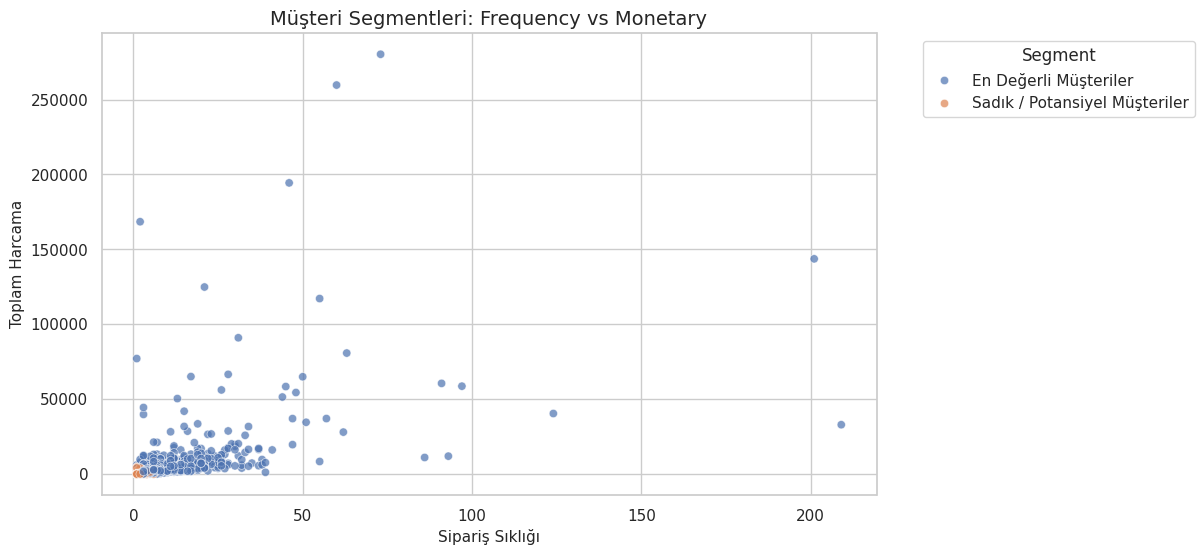

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="SegmentName",
    alpha=0.7
)

plt.title("Müşteri Segmentleri: Frequency vs Monetary")
plt.xlabel("Sipariş Sıklığı")
plt.ylabel("Toplam Harcama")
plt.legend(title="Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

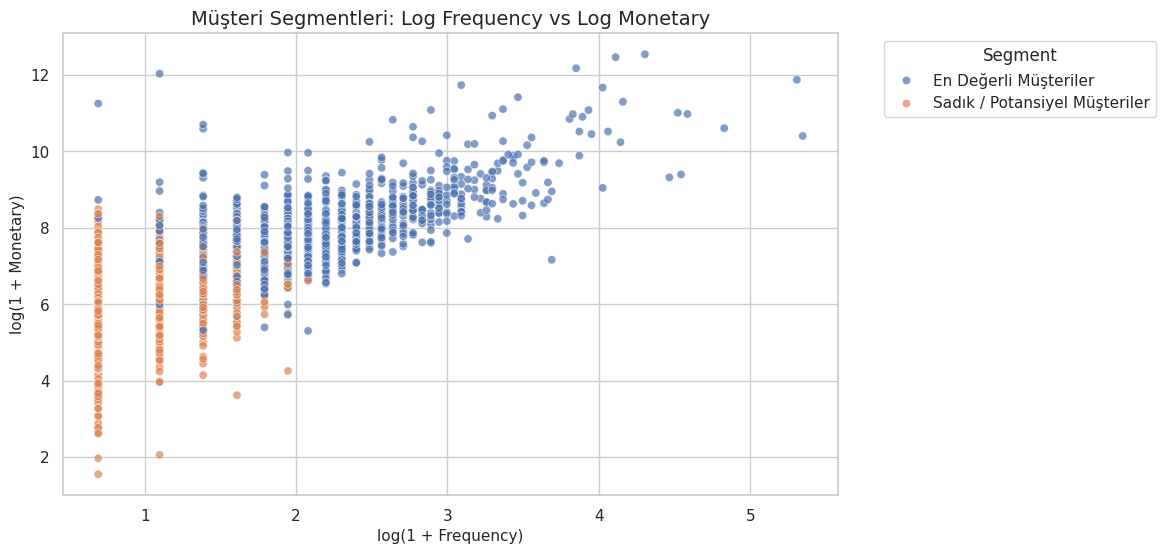

In [50]:
# Daha okunabilir görünüm için log eksenli scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm,
    x=np.log1p(rfm["Frequency"]),
    y=np.log1p(rfm["Monetary"]),
    hue=rfm["SegmentName"],
    alpha=0.7
)

plt.title("Müşteri Segmentleri: Log Frequency vs Log Monetary")
plt.xlabel("log(1 + Frequency)")
plt.ylabel("log(1 + Monetary)")
plt.legend(title="Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [51]:
for _, row in profile_with_names.sort_values("AvgMonetary", ascending=False).iterrows():
    print("=" * 80)
    print(f"Segment: {row['SegmentName']}")
    print(f"Müşteri sayısı: {row['CustomerCount']:.0f} (%{row['CustomerShare_%']:.2f})")
    print(f"Ortalama recency: {row['AvgRecency']:.1f} gün")
    print(f"Ortalama frequency: {row['AvgFrequency']:.1f} sipariş")
    print(f"Ortalama monetary: {row['AvgMonetary']:,.2f}")
    print(f"Toplam gelir payı: %{row['RevenueShare_%']:.2f}")

Segment: En Değerli Müşteriler
Müşteri sayısı: 1666 (%38.40)
Ortalama recency: 25.9 gün
Ortalama frequency: 8.4 sipariş
Ortalama monetary: 4,539.60
Toplam gelir payı: %85.10
Segment: Sadık / Potansiyel Müşteriler
Müşteri sayısı: 2672 (%61.60)
Ortalama recency: 134.1 gün
Ortalama frequency: 1.7 sipariş
Ortalama monetary: 495.59
Toplam gelir payı: %14.90
